# Install & Import Library

In [ ]:
!pip install optuna gensim spacy tensorflow scikit-learn

import numpy as np
import pandas as pd
import spacy
from gensim.models import KeyedVectors
import optuna
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


# Load spaCy Tokenizer (Indonesia)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
nlp = spacy.blank("id")  # tokenizer-only, paling cepat

def spacy_tokenize(text):
    return [t.text for t in nlp(text)]


# Load Dataset + Split Train/Val/Test :

In [ ]:
file_path = "/content/drive/MyDrive/NLP_Project/combined_dataset.csv"
df = pd.read_csv(file_path)

X = df["clean_text"].astype(str)
y = df["encoded_label"]

# Step 1: Test split 20%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 2: Validation 10% dari total → 12.5% dari 80%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=42
)

print(len(X_train), len(X_val), len(X_test))


1445 207 414


# Load FastText Embedding

In [ ]:
fasttext_path = "/content/drive/MyDrive/NLP_Project/cc.id.300.vec"

w2v = KeyedVectors.load_word2vec_format(fasttext_path, binary=False)

embedding_dim = 300


# Build Vocabulary + Convert to Sequence (Menggunakan spaCY)

In [ ]:
def build_vocab(texts):
    vocab = {}
    idx = 1  # 0 reserved for PAD

    for txt in texts:
        for tok in spacy_tokenize(txt):
            if tok not in vocab:
                vocab[tok] = idx
                idx += 1
    return vocab

vocab = build_vocab(X_train)
vocab_size = len(vocab) + 1


# Create embedding matrix:

In [ ]:
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, idx in vocab.items():
    if word in w2v:
        embedding_matrix[idx] = w2v[word]
    else:
        embedding_matrix[idx] = np.random.normal(size=(embedding_dim,))


# Convert text to indexed sequences:

In [ ]:
def text_to_sequence(text, vocab, max_len=40):
    tokens = spacy_tokenize(text)
    seq = [vocab.get(tok, 0) for tok in tokens][:max_len]
    seq += [0] * (max_len - len(seq))
    return seq

def convert_dataset(X):
    return np.array([text_to_sequence(t, vocab) for t in X])

X_train_vec = convert_dataset(X_train)
X_val_vec = convert_dataset(X_val)
X_test_vec = convert_dataset(X_test)


# Build Bi-GRU Model (with ReLU + Dropout)

In [ ]:
def build_model(h_units, dropout_rate, lr):

    inp = Input(shape=(40,))
    emb = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    )(inp)

    x = Bidirectional(GRU(h_units, return_sequences=False))(emb)
    x = Dropout(dropout_rate)(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(dropout_rate)(x)

    out = Dense(1, activation="sigmoid")(x)

    model = Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Final Training on Train + Val

In [ ]:
# {'h_units': 42, 'dropout': 0.24787681501663505, 'lr': 0.0016502625661843147}

best_h = 42
best_drop = 0.24787681501663505
best_lr = 0.0016502625661843147

final_model = build_model(best_h, best_drop, best_lr)

# Combine train + val
X_final = np.concatenate([X_train_vec, X_val_vec])
y_final = np.concatenate([y_train, y_val])

# Train final BiGRU
final_model.fit(
    X_final,
    y_final,
    epochs=10,
    batch_size=32,
    verbose=1
)

# === Evaluation on TEST set ===
from sklearn.metrics import f1_score, classification_report, confusion_matrix

y_pred = final_model.predict(X_test_vec)
y_pred = (y_pred > 0.5).astype(int).reshape(-1)

f1_macro = f1_score(y_test, y_pred, average="macro")
cls_report = classification_report(y_test, y_pred, output_dict=True)
cm = confusion_matrix(y_test, y_pred)

print("\n=== Final BiGRU Test Evaluation ===")
print("F1-macro:", f1_macro)
print("Accuracy:", cls_report["accuracy"])
print("Classification Report:", cls_report)
print("Confusion Matrix:\n", cm)

# === Inference Time Benchmark (selaras dengan BERT) ===
import time
benchmark_size = min(32, len(X_test_vec))
subset = X_test_vec[:benchmark_size]

# Warm-up
for _ in range(3):
    _ = final_model.predict(subset, verbose=0)

# Benchmark
n_runs = 50
start = time.time()
for _ in range(n_runs):
    _ = final_model.predict(subset, verbose=0)
end = time.time()

avg_time = (end - start) / n_runs
samples_per_second = benchmark_size / avg_time

print("\n🕒 Avg batch inference time:", avg_time)
print("📊 Throughput:", samples_per_second, "samples/sec")

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6011 - loss: 0.6731
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7888 - loss: 0.4860
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8547 - loss: 0.3187
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8912 - loss: 0.2694
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8955 - loss: 0.2619
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9301 - loss: 0.1836
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9442 - loss: 0.1500
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9414 - loss: 0.1457
Epoch 9/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9629 - loss: 0.1177
Epoch 10/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9501 - loss: 0.1281
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

=== Final BiGRU Test Evaluation ===
F1-macro: 0.8645827757854734
Accuracy: 0.8671497584541062
Classification Report: {

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
              precision    recall  f1-score   support

         0.0     0.8560    0.9123    0.8832       228
         1.0     0.8830    0.8118    0.8459       186

    accuracy                         0.8671       414
   macro avg     0.8695    0.8621    0.8646       414
weighted avg     0.8681    0.8671    0.8665       414



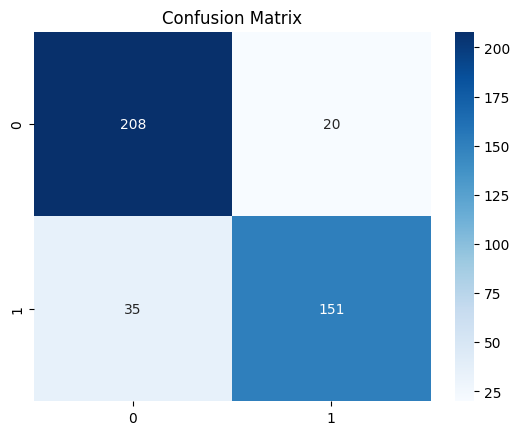

Macro F1: 0.8645827757854734


In [ ]:
y_pred = (final_model.predict(X_test_vec) > 0.5).astype("int32")

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print("Macro F1:", f1_score(y_test, y_pred, average="macro"))